# LIBS

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv("Car details v3.csv")

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB
None


In [5]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [6]:
df = df.drop(['torque', 'name'], axis=1)

In [7]:
df['engine'] = df['engine'].str.replace(' CC', '')
df['max_power'] = df['max_power'].str.replace(' bhp', '')
df['mileage'] = df['mileage'].str.replace(' kmpl', '')

In [8]:
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

In [9]:
df.isnull().sum()

year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          309
engine           221
max_power        216
seats            221
dtype: int64

In [10]:
df['mileage'] = df['mileage'].fillna(df['mileage'].median())
df['engine'] = df['engine'].fillna(df['engine'].median())
df['max_power'] = df['max_power'].fillna(df['max_power'].median())
df['seats'] = df['seats'].fillna(df['seats'].median())

In [11]:
df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [12]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [13]:
df = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'owner'], drop_first=True)

In [14]:
df.head()

,year,selling_price,km_driven,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,23.40,1248.0,74.00,5.0,True,False,False,True,False,True,False,False,False,False
1,2014,370000,120000,21.14,1498.0,103.52,5.0,True,False,False,True,False,True,False,True,False,False
2,2006,158000,140000,17.70,1497.0,78.00,5.0,False,False,True,True,False,True,False,False,False,True
3,2010,225000,127000,23.00,1396.0,90.00,5.0,True,False,False,True,False,True,False,False,False,False
4,2007,130000,120000,16.10,1298.0,88.20,5.0,False,False,True,True,False,True,False,False,False,False


In [15]:
df['age'] = 2026 - df['year']
df = df.drop('year', axis=1)

In [16]:
df.head()

,selling_price,km_driven,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,age
0,450000,145500,23.40,1248.0,74.00,5.0,True,False,False,True,False,True,False,False,False,False,12
1,370000,120000,21.14,1498.0,103.52,5.0,True,False,False,True,False,True,False,True,False,False,12
2,158000,140000,17.70,1497.0,78.00,5.0,False,False,True,True,False,True,False,False,False,True,20
3,225000,127000,23.00,1396.0,90.00,5.0,True,False,False,True,False,True,False,False,False,False,16
4,130000,120000,16.10,1298.0,88.20,5.0,False,False,True,True,False,True,False,False,False,False,19


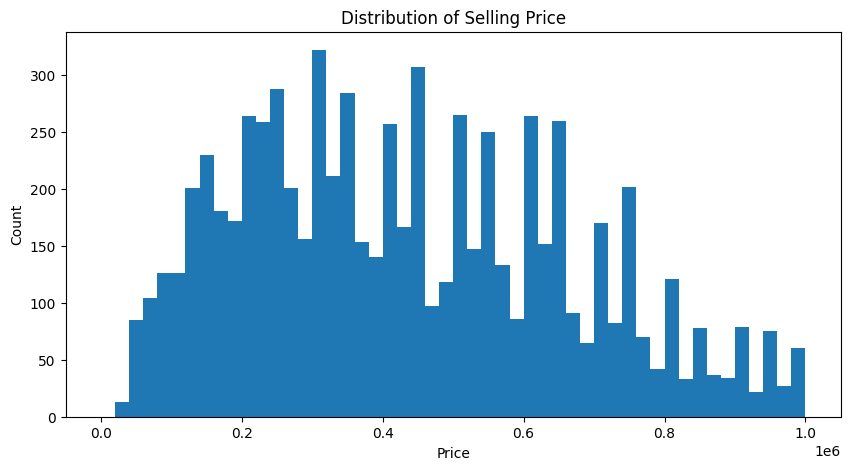

In [17]:

plt.figure(figsize=(10,5))
plt.hist(df['selling_price'], bins=50, range=(0, 1000000))
plt.title("Distribution of Selling Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

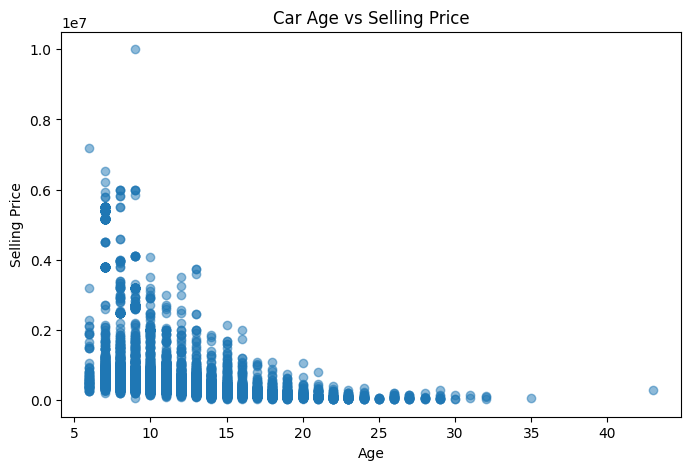

In [18]:

plt.figure(figsize=(8,5))
plt.scatter(df['age'], df['selling_price'], alpha=0.5)
plt.title("Car Age vs Selling Price")
plt.xlabel("Age")
plt.ylabel("Selling Price")
plt.show()

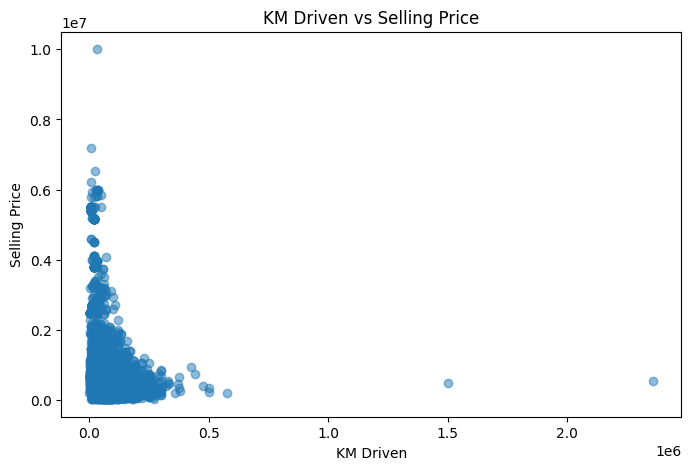

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(df['km_driven'], df['selling_price'], alpha=0.5)
plt.title("KM Driven vs Selling Price")
plt.xlabel("KM Driven")
plt.ylabel("Selling Price")
plt.show()

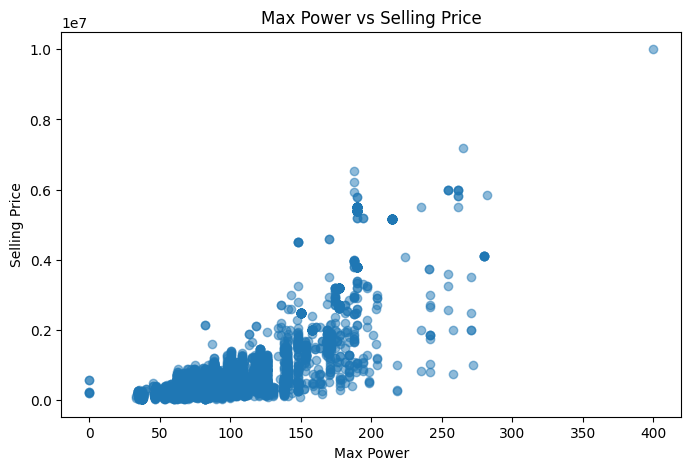

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(df['max_power'], df['selling_price'], alpha=0.5)
plt.title("Max Power vs Selling Price")
plt.xlabel("Max Power")
plt.ylabel("Selling Price")
plt.show()

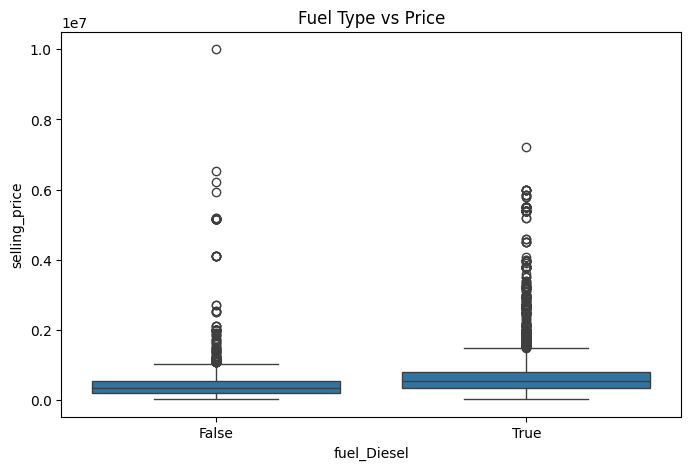

In [21]:

plt.figure(figsize=(8,5))
sns.boxplot(x='fuel_Diesel', y='selling_price', data=df)
plt.title("Fuel Type vs Price")
plt.show()

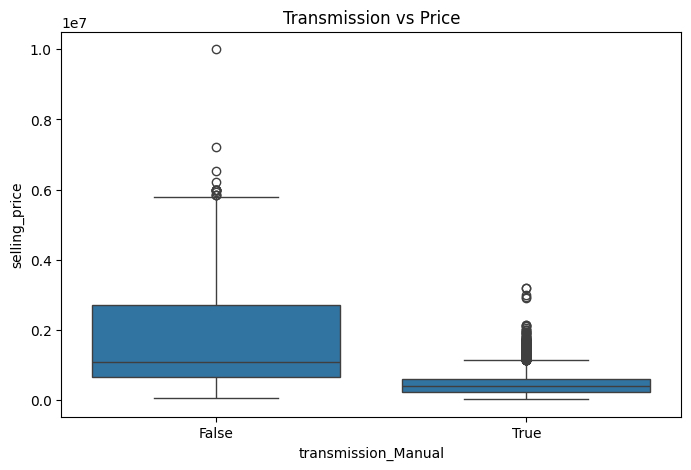

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='transmission_Manual', y='selling_price', data=df)
plt.title("Transmission vs Price")
plt.show()

In [23]:

X = df.drop('selling_price', axis=1)
y = df['selling_price']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [25]:


# =========================
# Models + Results
# =========================
results = []

def add_result(name, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append([name, r2, rmse])

# -------------------------
# Linear Regression
# -------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)
add_result("Linear Regression", lr.predict(X_test))

# -------------------------
# Polynomial Regression
# -------------------------
poly = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly.fit(X_train, y_train)
add_result("Polynomial Regression", poly.predict(X_test))

# -------------------------
# Ridge
# -------------------------
ridge = Ridge()
ridge.fit(X_train, y_train)
add_result("Ridge", ridge.predict(X_test))

# -------------------------
# Lasso
# -------------------------
lasso = Lasso()
lasso.fit(X_train, y_train)
add_result("Lasso", lasso.predict(X_test))

# -------------------------
# ElasticNet
# -------------------------
elastic = ElasticNet()
elastic.fit(X_train, y_train)
add_result("ElasticNet", elastic.predict(X_test))

# -------------------------
# Decision Tree
# -------------------------
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
add_result("Decision Tree", dt.predict(X_test))

# -------------------------
# Random Forest
# -------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
add_result("Random Forest", rf.predict(X_test))

# -------------------------
# KNN
# -------------------------
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
add_result("KNN", knn.predict(X_test))



# =========================
# FINAL TABLE
# =========================
df_results = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])
df_results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,RMSE
6,Random Forest,0.969101,142315.321334
7,KNN,0.945645,188756.340074
1,Polynomial Regression,0.914611,236582.517267
5,Decision Tree,0.908474,244936.360003
0,Linear Regression,0.697782,445083.627997
3,Lasso,0.697781,445084.061697
2,Ridge,0.697778,445086.610345
4,ElasticNet,0.657964,473497.075056


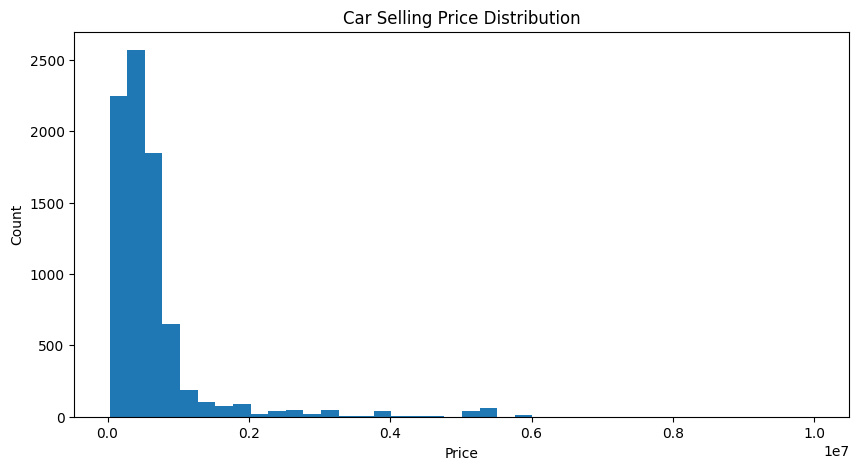

In [26]:
plt.figure(figsize=(10,5))
plt.hist(df['selling_price'], bins=40)
plt.title("Car Selling Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [27]:
X_simple = df[['age']]
y = df['selling_price']

# split جديد مخصوص للـ simple model
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# model
simple_lr = LinearRegression()
simple_lr.fit(X_train_s, y_train_s)

# prediction
pred = simple_lr.predict(X_test_s)

# evaluation
print("Simple Linear Regression")
print("R2  :", r2_score(y_test_s, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_s, pred)))

Simple Linear Regression
R2  : 0.17176137843746886
RMSE: 736815.8042390589


In [28]:
# =========================
# Model
# =========================
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

svr.fit(X_train, y_train)

# =========================
# Prediction
# =========================
pred = svr.predict(X_test)

# =========================
# Evaluation
# =========================
print("SVR Regression")
print("R2  :", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

SVR Regression
R2  : -0.027371147984120103
RMSE: 820625.2506621244


In [29]:
import joblib

joblib.dump(rf, "rf_model.pkl")
joblib.dump(knn, "knn_model.pkl")
joblib.dump(dt, "dt_model.pkl")
joblib.dump(poly, "poly_model.pkl")

['poly_model.pkl']